# Notebook Dedicated to Construct the Time Residual Distriburions of the Dataset 

In [7]:
import uproot
import numpy as np
import glob
import os

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter
import seaborn as sn


# Load Data

In [27]:
# Directories
main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis*/ratds_data/*.root'
flist = glob.glob(main_dir)

time_res = np.array([])

#Time residual cuts
time_res_inf_cut = -5.0
time_res_sup_cut = 10

for file_i in flist:

    print(f'reading File {file_i}')

    f_load = uproot.open(file_i)
    event_data = f_load['T;1']
    time_res_i = np.array(event_data['hit_residual'])

    time_res_cut = (time_res_i >= time_res_inf_cut) & (time_res_i <= time_res_sup_cut)
    time_res_i = time_res_i[time_res_cut]

    time_res = np.append(time_res, time_res_i)

print('Done')

    

reading File /home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis20_bMR/ratds_data/analysis_ratds_sum_0.root
reading File /home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis20_bMR/ratds_data/analysis_ratds_sum_30.root
reading File /home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis20_bMR/ratds_data/analysis_ratds_sum_13.root
reading File /home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis20_bMR/ratds_data/analysis_ratds_sum_62.root
reading File /home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis20_bMR/ratds_data/analysis_ratds_sum_59.root
reading File /home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis20_bMR/ratds_data/analysis_ratds_sum_32.root
reading File /home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis20_bMR/ratds_data/analysis_ratds_sum_42.root
reading File /home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analys

# Time Residual Plot

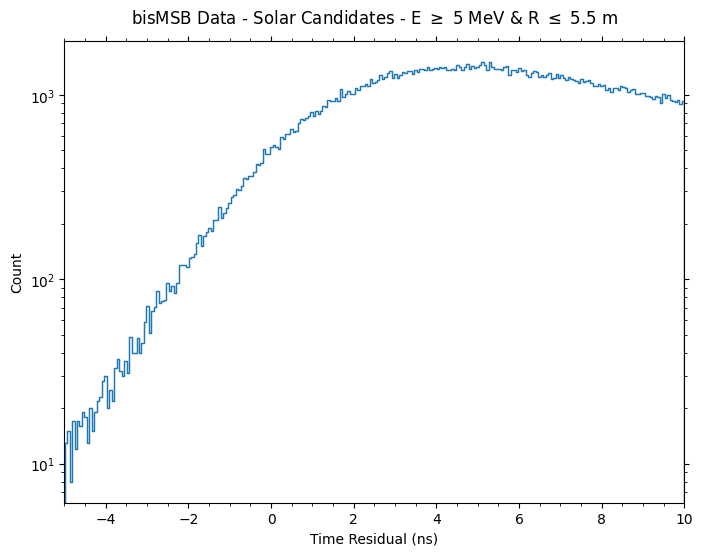

In [46]:
fig, ax = plt.subplots(figsize=(8,6))

bins = 250

sn.histplot(time_res, bins = bins, element = 'step', alpha = 0, linewidth = 1.06)

plt.xlabel('Time Residual (ns)')
plt.title(rf'bisMSB Data - Solar Candidates - E $\geq$ 5 MeV & R $\leq$ 5.5 m', y = 1.02)

plt.yscale('log')
plt.xlim(time_res_inf_cut, time_res_sup_cut)

ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.xaxis.set_major_locator(MultipleLocator(2))

ax.tick_params(which='minor', top=True, bottom=True, left=True, right=True)
ax.tick_params(which='major', top=True, bottom=True, left=True, right=True)

plt.show()